In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
train=pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv')
test=pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')

train.head()

/kaggle/input/playground-series-s5e5/sample_submission.csv
/kaggle/input/playground-series-s5e5/train.csv
/kaggle/input/playground-series-s5e5/test.csv


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e5/sample_submission.csv
/kaggle/input/playground-series-s5e5/train.csv
/kaggle/input/playground-series-s5e5/test.csv


In [3]:
print(train.isnull().sum())
train.shape


id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


(750000, 9)

In [4]:
train.nunique()
#all ids are unique so no duplicates 

id            750000
Sex                2
Age               60
Height            86
Weight            91
Duration          30
Heart_Rate        63
Body_Temp         75
Calories         277
dtype: int64

In [5]:
train.describe()
#observations:: 1 min workouts? ,,41.5 is very high body temp(outlier)?,,//calories 1-314(skewed?)// heart rate and duration correelation?
#duration and body_Temp and calroiess?? ,,height might have outliers?

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
gender_distribution= train['Sex'].value_counts()
print(gender_distribution)
##gender is distributed equally , no need for smote or undersampling.etc.

Sex
female    375721
male      374279
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

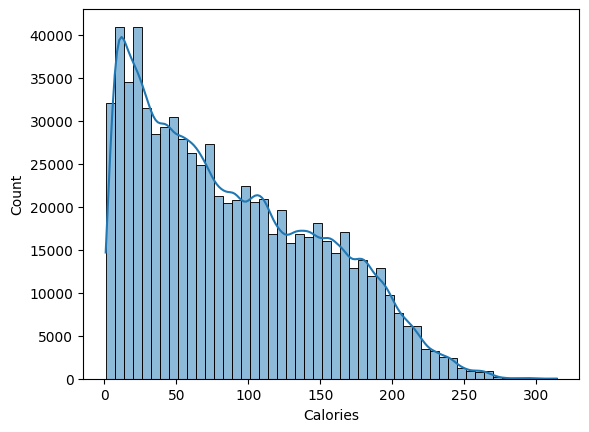

In [7]:
##checking outliers and skewness
import seaborn as sns
import matplotlib.pyplot as plt

##calories distribution
sns.histplot(train['Calories'],bins=50,kde=True)
plt.show

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Calories_log', ylabel='Count'>

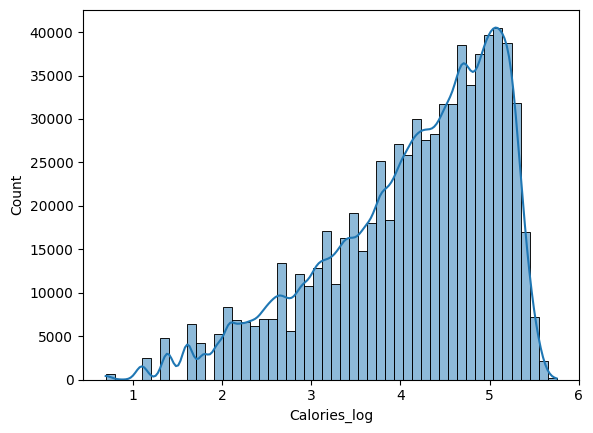

In [8]:
#Calories values are rght skewed. hence the log transformation
train['Calories_log']=np.log1p(train['Calories'])
sns.histplot(train['Calories_log'],bins=50,kde=True)

In [9]:
##now appears to be left skewed// exoected but lets check
from scipy.stats import skew,kurtosis
print(skew(train['Calories_log']))
print(kurtosis(train['Calories_log']))

## skewness is fine for now , -0.85, but after first submission , revisit and try further transformations.

-0.8570117934466557
0.1121544400730432


In [10]:
X=train.drop(['id','Calories','Calories_log'],axis=1)
X.head

<bound method NDFrame.head of            Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0         male   36   189.0    82.0      26.0       101.0       41.0
1       female   64   163.0    60.0       8.0        85.0       39.7
2       female   51   161.0    64.0       7.0        84.0       39.8
3         male   20   192.0    90.0      25.0       105.0       40.7
4       female   38   166.0    61.0      25.0       102.0       40.6
...        ...  ...     ...     ...       ...         ...        ...
749995    male   28   193.0    97.0      30.0       114.0       40.9
749996  female   64   165.0    63.0      18.0        92.0       40.5
749997    male   60   162.0    67.0      29.0       113.0       40.9
749998    male   45   182.0    91.0      17.0       102.0       40.3
749999  female   39   171.0    65.0      19.0        97.0       40.6

[750000 rows x 7 columns]>

In [11]:
X['Sex']=X['Sex'].map(({'male':0,'female':1}))
X.head
print(X.columns)

Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


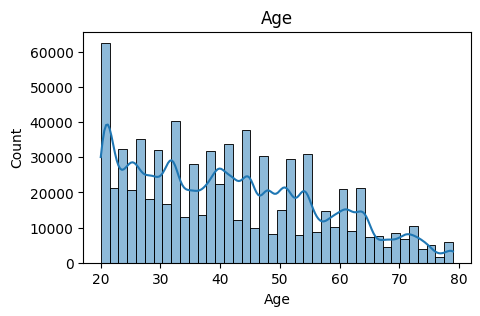

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


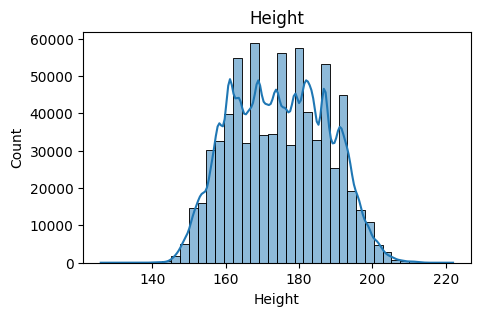

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


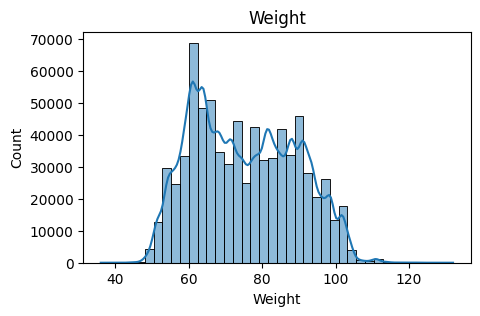

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


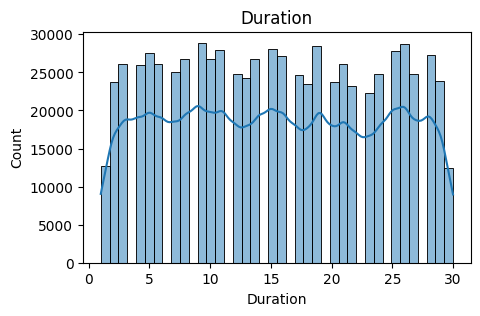

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


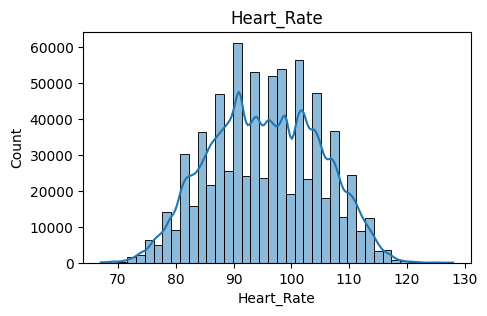

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


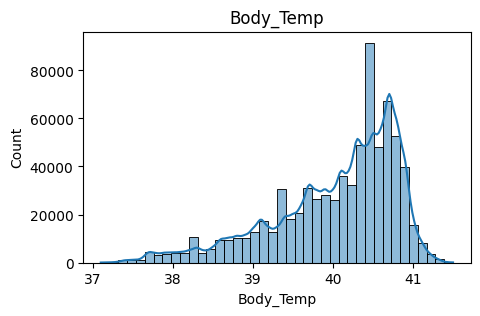

In [12]:
##lets check skewnwss for all other features
numerical_cols=['Age','Height','Weight','Duration','Heart_Rate','Body_Temp']

for cols in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(X[cols],kde=True,bins=40)
    plt.title(cols)
    plt.show()

In [13]:
#age is right skewed(more younger users,than older,,square root can smooth it)


#height is almost perfect ,bell-shaped

##weight is right skewed slightly, StandardScaler should be fine(can use log.cox-box)


##Duration very uniform/slighlty flat (valuable feature)

##Heart_Rate nicely bell-shaped,a little skew right 


##body temp , slighlty right-skewed,some tight clusters

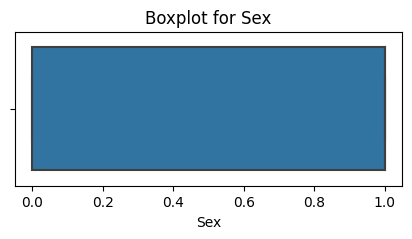

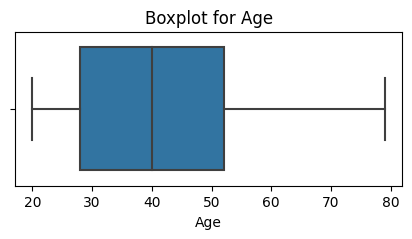

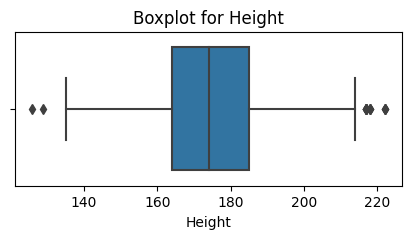

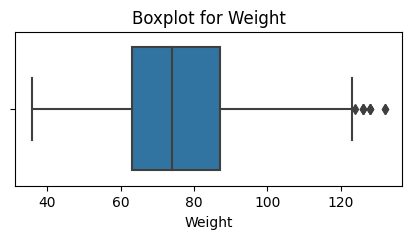

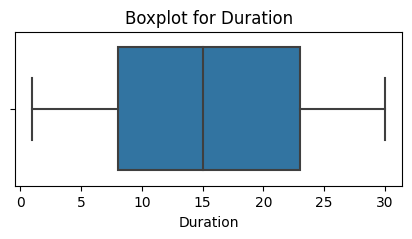

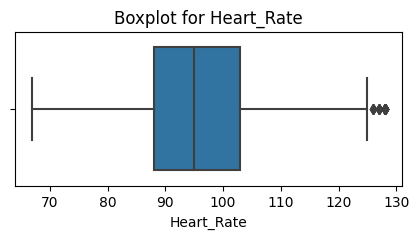

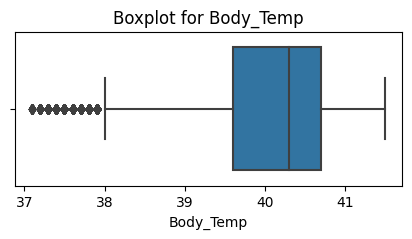

In [14]:
for cols in X.columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=X[cols])
    plt.title(f'Boxplot for {cols}')
    plt.show()

###reading box plots

In [15]:
from scipy.stats import zscore

z_scores=np.abs(zscore(X))
outlier_percent=(z_scores > 3).mean(axis=0)*100 #percent of values with z>3 per feature
print(outlier_percent)

[0.         0.         0.00506667 0.01386667 0.         0.02333333
 0.44906667]


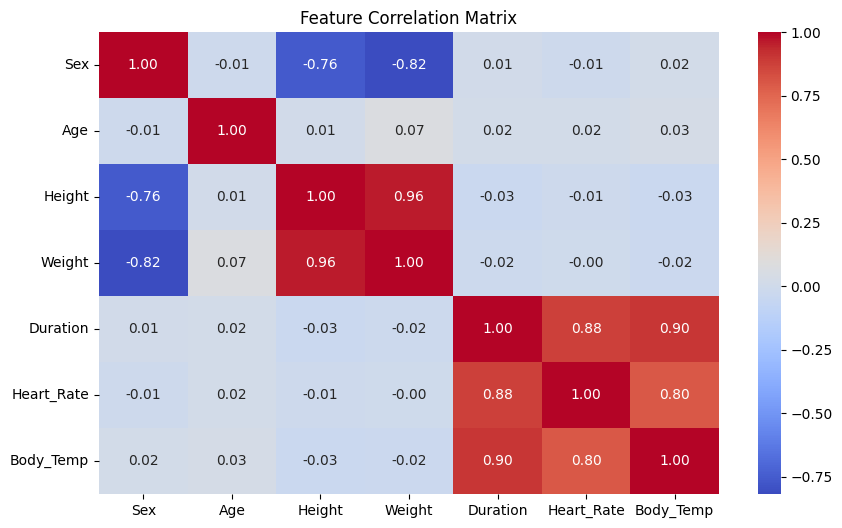

In [16]:
plt.figure(figsize=(10,6))
corr_matrix=X.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
##high coorelation between weight and height, maybe add a feaure BMI?
X['BMI']=X['Weight']/((X['Height']/100)**2)

##DROP original weight/height
X.drop(['Weight','Height'],axis=1,inplace=True)


In [18]:
X.head

<bound method NDFrame.head of         Sex  Age  Duration  Heart_Rate  Body_Temp        BMI
0         0   36      26.0       101.0       41.0  22.955684
1         1   64       8.0        85.0       39.7  22.582709
2         1   51       7.0        84.0       39.8  24.690405
3         0   20      25.0       105.0       40.7  24.414062
4         1   38      25.0       102.0       40.6  22.136740
...     ...  ...       ...         ...        ...        ...
749995    0   28      30.0       114.0       40.9  26.040968
749996    1   64      18.0        92.0       40.5  23.140496
749997    0   60      29.0       113.0       40.9  25.529645
749998    0   45      17.0       102.0       40.3  27.472527
749999    1   39      19.0        97.0       40.6  22.229062

[750000 rows x 6 columns]>

In [19]:
from sklearn.preprocessing import StandardScaler 

scaler=StandardScaler()
X_scaled =pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

In [20]:
X_scaled.head

<bound method NDFrame.head of              Sex       Age  Duration  Heart_Rate  Body_Temp       BMI
0      -1.001925 -0.357192  1.266324    0.583714   1.235772 -0.939009
1       0.998079  1.487943 -0.888309   -1.109436  -0.431163 -1.185799
2       0.998079  0.631273 -1.008011   -1.215258  -0.302938  0.208818
3      -1.001925 -1.411555  1.146622    1.007002   0.851095  0.025968
4       0.998079 -0.225397  1.146622    0.689536   0.722869 -1.480887
...          ...       ...       ...         ...        ...       ...
749995 -1.001925 -0.884374  1.745131    1.959399   1.107547  1.102455
749996  0.998079  1.487943  0.308709   -0.368683   0.594643 -0.816723
749997 -1.001925  1.224352  1.625430    1.853577   1.107547  0.764124
749998 -1.001925  0.235887  0.189007    0.689536   0.338192  2.049687
749999  0.998079 -0.159499  0.428411    0.160427   0.722869 -1.419799

[750000 rows x 6 columns]>

In [21]:
print(train['Calories'])

0         150.0
1          34.0
2          29.0
3         140.0
4         146.0
          ...  
749995    230.0
749996     96.0
749997    221.0
749998    109.0
749999    103.0
Name: Calories, Length: 750000, dtype: float64


In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_scaled,train['Calories_log'])

LinearRegression()

In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict on training set
y_train_pred_log = model.predict(X_scaled)
y_train_pred = np.expm1(y_train_pred_log)
y_train_true = np.expm1(train['Calories_log'])


rmse = mean_squared_error(y_train_true, y_train_pred, squared=False)
print("Train RMSE:", rmse)


Train RMSE: 18.054589949976137


In [24]:
##test set:
test['Sex'] = test['Sex'].str.lower().map({'male': 0, 'female': 1})


###create a BMI
test['BMI']=test['Weight']/((test['Height']/100)**2)

##dropiiing columns
X_test = test.drop(["id","Weight","Height"],axis=1).copy()

X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)
                  

In [25]:
print(X_test.isnull().sum())
X_test.info()



Sex           0
Age           0
Duration      0
Heart_Rate    0
Body_Temp     0
BMI           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         250000 non-null  int64  
 1   Age         250000 non-null  int64  
 2   Duration    250000 non-null  float64
 3   Heart_Rate  250000 non-null  float64
 4   Body_Temp   250000 non-null  float64
 5   BMI         250000 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 11.4 MB


In [26]:
y_test_pred_log = model.predict(X_test_scaled)

y_test_pred =np.expm1(y_test_pred_log)

submission=pd.DataFrame({'id':test['id'],'Calories': y_test_pred})
submission.to_csv('submission.csv',index=False)

In [27]:
submission.head()

,id,Calories
0,750000,33.724731
1,750001,98.060970
2,750002,90.126270
3,750003,138.704117
4,750004,79.115921
